In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import re

In [49]:
#importing the fake news dataset
df1 = pd.read_csv('Fake.csv', encoding='latin-1')
df1.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [50]:
#importing the true news dataset
df2 = pd.read_csv('True.csv', encoding='latin-1')
df2.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [51]:
#cheking null values in the dataset
df1.info()
print("---------------------------------------------")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
---------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [52]:
df1.shape, df2.shape

((23481, 4), (21417, 4))

In [53]:
df1 = df1.drop([ 'subject', 'date'], axis=1)
df2 = df2.drop([ 'subject', 'date'], axis=1)
df1['label'] = 0
df2['label'] = 1


In [54]:
df1.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [55]:
df2.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [56]:
df = pd.concat([df1, df2], axis=0, ignore_index=True)
df.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [57]:
df.shape

(44898, 3)

In [58]:
#stemming, lemantization, removing stop words and tokenizing the text

def preprocess_text(text):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Stemming
    stemmer = SnowballStemmer('english')
    tokens = [stemmer.stem(word) for word in tokens]
    lematizer = WordNetLemmatizer()
    tokens = [lematizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['text'] = df['text'].apply(preprocess_text)
df['title'] = df['title'].apply(preprocess_text)
df.head()

,title,text,label
0,donald trump send embarrass new year eve messa...,donald trump wish american happi new year leav...,0
1,drunk brag trump staffer start russian collus ...,hous intellig committe chairman devin nune go ...,0
2,sheriff david clark becom internet joke threat...,friday reveal former milwauke sheriff david cl...,0
3,trump obsess even obama name code websit imag,christma day donald trump announc would back w...,0
4,pope franci call donald trump christma speech,pope franci use annual christma day messag reb...,0


In [ ]:

# Splitting the dataset into training and testing sets
X = df['text'] + ' ' + df['title']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
#vectorizing the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(X_train)
print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Sample vocabulary:", list(vectorizer.vocabulary_.keys())[:10])
# Transforming the text data into TF-IDF vectors
X_train_vectorized = vectorizer.transform(X_train).toarray()
X_test_vectorized = vectorizer.transform(X_test).toarray()

Vocabulary size: 5000
Sample vocabulary: ['republican', 'frontrunn', 'donald', 'trump', 'pretti', 'amaz', 'job', 'make', 'look', 'like']


In [75]:
print("Shape of training data:", X_train_vectorized.shape)
print("Shape of testing data:", X_test_vectorized.shape)

Shape of training data: (22449, 5000)
Shape of testing data: (22449, 5000)


In [76]:
# Training the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vectorized, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [78]:
# evaluating the model
y_pred = model.predict(X_test_vectorized)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9846763775669295
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99     11683
           1       0.98      0.99      0.98     10766

    accuracy                           0.98     22449
   macro avg       0.98      0.98      0.98     22449
weighted avg       0.98      0.98      0.98     22449

Confusion Matrix:
 [[11473   210]
 [  134 10632]]


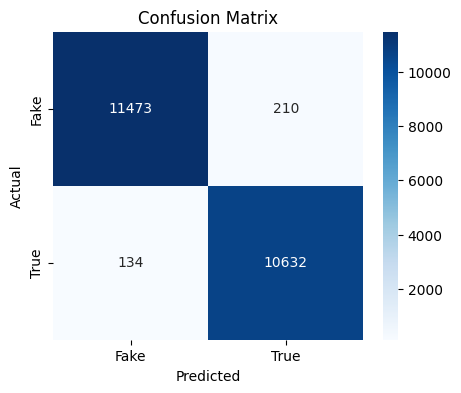

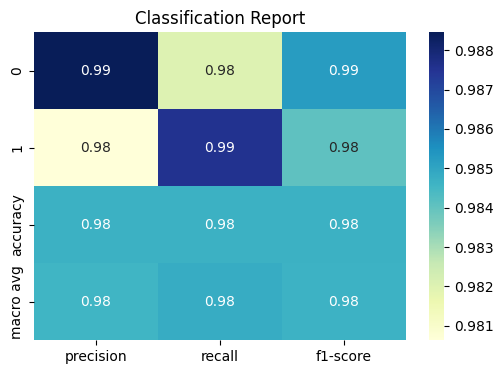

In [79]:
import seaborn as sns

import matplotlib.pyplot as plt

# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Visualize the classification report as a heatmap
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(6,4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='YlGnBu')
plt.title('Classification Report')
plt.show()

In [81]:
#cheking the training accuracy of the model
train_accuracy = model.score(X_train_vectorized, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9893091006280903


In [80]:
# predicting the class of a new text
def predict_news_class(text):
    # Preprocess the text
    text = preprocess_text(text)
    # Transform the text into TF-IDF vector
    text_vectorized = vectorizer.transform([text]).toarray()
    # Predict the class
    prediction = model.predict(text_vectorized)
    return "Fake" if prediction[0] == 0 else "True"
# Example usage
text = "The stock market is crashing! Experts say it's the end of the world."
print("Predicted class:", predict_news_class(text))

Predicted class: Fake


In [110]:
#saiving the model
import joblib
joblib.dump(model, 'fake_news_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']

In [ ]:
import requests
from bs4 import BeautifulSoup

def fetch_cnn_headlines():
    url = "https://edition.cnn.com/world"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    }
    r = requests.get(url, headers=headers, timeout=10)
    print("Status Code:", r.status_code)
    print(r.text[:1000])  # Print the first 1000 characters of the response
    try:
        r = requests.get(url, headers=headers, timeout=10)
    except requests.exceptions.RequestException as e:
        print("Request failed:", e)
        return []
    soup = BeautifulSoup(r.text, 'html.parser')
    headlines = []

    for article in soup.select("h3.cd__headline"):
        text = article.get_text(strip=True)
        if text:
            headlines.append(text)
    return headlines[:10]



def fetch_bbc_headlines():
    url = "https://www.bbc.com/news"
    r = requests.get(url)
    
    soup = BeautifulSoup(r.text, 'html.parser')
    headlines = []

    for h3 in soup.select("h3.gs-c-promo-heading__title"):
        text = h3.get_text(strip=True)
        if text and len(text) > 30:  # filter short ones
            headlines.append(text)
    return headlines[:10]


# Fetch headlines
cnn_headlines = fetch_cnn_headlines()
bbc_headlines = fetch_bbc_headlines()

# Combine and predict
all_headlines = [("CNN", h) for h in cnn_headlines] + [("BBC", h) for h in bbc_headlines]
print("Fetched Headlines:",all_headlines)

for source, headline in all_headlines:
    processed = preprocess_text(headline)
    vect = vectorizer.transform([processed]).toarray()
    pred = model.predict(vect)[0]
    label = "Fake" if pred == 0 else "Real"
    print(f"[{source}] {headline}\nPrediction: {label}\n{'-'*60}")


Status Code: 200
  <!DOCTYPE html>
<html lang="en" data-uri="cms.cnn.com/_pages/cl9wqykfb000026p95p1gfx93@published" data-layout-uri="cms.cnn.com/_layouts/layout-no-rail/instances/world-v1@published" >
  <head>
<link rel="dns-prefetch" href="//tpc.googlesyndication.com">

<link rel="preconnect" href="//tpc.googlesyndication.com">

<link rel="dns-prefetch" href="//pagead2.googlesyndication.com">

<link rel="preconnect" href="//pagead2.googlesyndication.com">

<link rel="dns-prefetch" href="//www.googletagservices.com">

<link rel="preconnect" href="//www.googletagservices.com">

<link rel="dns-prefetch" href="//www.google.com">

<link rel="preconnect" href="//www.google.com">

<link rel="dns-prefetch" href="//c.amazon-adsystem.com">

<link rel="preconnect" href="//c.amazon-adsystem.com">

<link rel="dns-prefetch" href="//ib.adnxs.com">

<link rel="preconnect" href="//ib.adnxs.com">

<link rel="dns-prefetch" href="//cdn.adsafeprotected.com">

<link rel="preconnect" href="//cdn.adsafeprot

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import time

def fetch_cnn_headlines():
    options = Options()
    options.headless = True
    driver = webdriver.Chrome(options=options)

    driver.get("https://edition.cnn.com/world")
    time.sleep(5)  # wait for JS content to load

    soup = BeautifulSoup(driver.page_source, 'html.parser')
    # print(soup.prettify()[:2000])  # Print the first 1000 characters of the soup
    headlines = []

    # Inspect CNN and look for class like this:
    for headline in soup.select('span.container__headline-text'):
        text = headline.get_text(strip=True)
        if text:
            headlines.append(text)

    driver.quit()
    return headlines[:10]

cnn_headlines = fetch_cnn_headlines()

for headline in cnn_headlines:
    processed = preprocess_text(headline)
    vect = vectorizer.transform([processed]).toarray()
    pred = model.predict(vect)[0]
    label = "Fake" if pred == 0 else "Real"
    print(f"[CNN] {headline}\nPrediction: {label}\n{'-'*60}")


<html class="userconsent-cntry-in userconsent-state-ap userconsent-reg-global" data-layout-uri="cms.cnn.com/_layouts/layout-no-rail/instances/world-v1@published" data-uri="cms.cnn.com/_pages/cl9wqykfb000026p95p1gfx93@published" lang="en">
 <head>
  <script async="" src="//www.i.cdn.cnn.com/zion/zion-mb.min.js" type="text/javascript">
  </script>
  <script async="" src="https://cdn.boomtrain.com/p13n/cnn/p13n.min.js">
  </script>
  <script async="" data-nscript="beforeInteractive" id="btScript" src="https://warnermediagroup-com.videoplayerhub.com/galleryloader.js" type="text/javascript">
  </script>
  <script async="" id="GPTScript" src="https://securepubads.g.doubleclick.net/tag/js/gpt.js" type="text/javascript">
  </script>
  <script async="" data-nscript="beforeInteractive" id="guid" src="https://www.ugdturner.com/xd.sjs" type="text/javascript">
  </script>
  <script async="" data-nscript="beforeInteractive" id="ias" src="https://cdn.adsafeprotected.com/iasPET.1.js" type="text/javasc

In [109]:
for headline in cnn_headlines:
    processed = preprocess_text(headline)
    vect = vectorizer.transform([processed]).toarray()
    pred = model.predict(vect)[0]
    label = "Fake" if pred == 0 else "Real"
    print(f"[ {label}\n{'-'*60}")


[ Fake
------------------------------------------------------------
[ Fake
------------------------------------------------------------
[ Real
------------------------------------------------------------
[ Real
------------------------------------------------------------
[ Fake
------------------------------------------------------------
[ Fake
------------------------------------------------------------
[ Fake
------------------------------------------------------------
[ Fake
------------------------------------------------------------
[ Fake
------------------------------------------------------------
[ Fake
------------------------------------------------------------
